In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tqdm

list(tqdm.tqdm(range(6,10)))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 33026.02it/s]


[2, 3]

In [4]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu0'
number_of_hf_repo_files= 100
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [5]:
from primary.create_trainning_dataset import preprocess_for_model
result = preprocess_for_model(particles, tracks, calo_hits, num_of_events=1000, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3, clusters_cutoff=0.1)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1000 events. Time: 0.76s
Workload optimized: 1000 events merged into 1000 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 258.53s
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from 

In [6]:
target_particles_deps = result['target_particles_deps']
calos = result['calo_clusters']
target_particles = result['target_particles']

In [7]:
target_particles = target_particles.with_columns(
    particle_idx=pl.int_ranges(0, pl.col("particle_id").list.len())
)

In [54]:
target_particles_deps

event_id,total_energy_deps_in_cluster,particle_idx,cluster_idx
u32,list[f64],list[u32],list[u32]
0,"[117.038543, 0.53211, … 0.102913]","[17, 29, … 2]","[0, 1, … 209]"
1,"[127.031119, 0.040184, … 0.205484]","[37, 42, … 47]","[0, 0, … 245]"
2,"[4.454301, 15.864806, … 0.163612]","[120, 114, … 55]","[0, 0, … 360]"
3,"[6.561038, 5.002248, … 0.120772]","[17, 120, … 14]","[0, 0, … 427]"
4,"[8.067035, 12.765588, … 1.176899]","[39, 43, … 14]","[0, 0, … 287]"
…,…,…,…
995,"[11.485494, 1.991656, … 0.106362]","[31, 133, … 92]","[0, 0, … 580]"
996,"[1.5157, 0.086862, … 0.838095]","[43, 149, … 14]","[0, 0, … 589]"
997,"[136.480148, 1.572651, … 0.106736]","[63, 78, … 41]","[0, 0, … 617]"


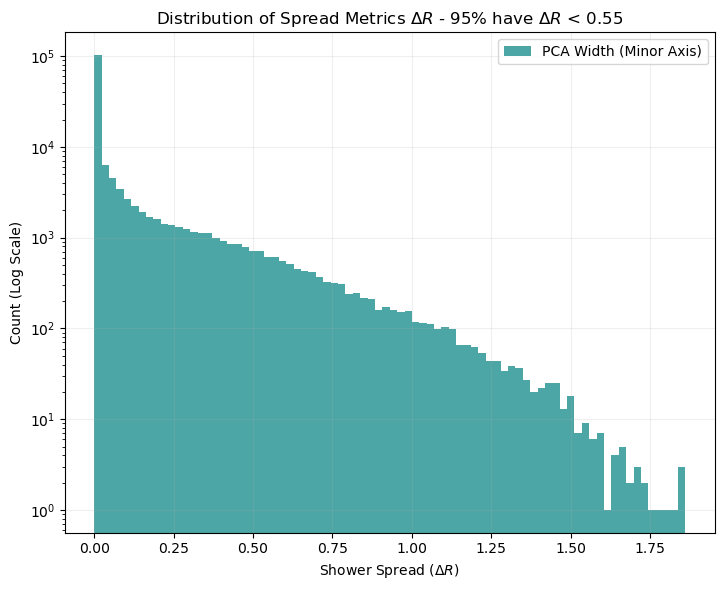

In [27]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Prepare and Flatten Data
# ==============================================================================

# Flatten dependencies (Particle -> Cluster mapping)
deps_flat = (
    target_particles_deps
    .explode(["particle_idx", "cluster_idx", "total_energy_deps_in_cluster"])
    .select([
        "event_id",
        "particle_idx",
        "cluster_idx",
        "total_energy_deps_in_cluster",
    ])
    .filter(pl.col("total_energy_deps_in_cluster") >= 0.1)
)

# Flatten Calorimeter clusters
calos_flat = (
    calos.explode(["cluster_id", "cluster_phi", "cluster_eta"])
    .select(["event_id", "cluster_id", "cluster_phi", "cluster_eta"])
)

# Merge to get coordinates for every cluster associated with a particle
merged = deps_flat.join(
    calos_flat,
    left_on=["event_id", "cluster_idx"],
    right_on=["event_id", "cluster_id"],
    how="inner"
)

# ==============================================================================
# 2. Calculate ENERGY-WEIGHTED Centroids and Deltas
# ==============================================================================

# Calculate Weighted Mean Eta and Weighted Vector Mean Phi
merged_with_means = merged.with_columns([
    # Weighted Eta: sum(eta * energy) / sum(energy)
    (
        (pl.col("cluster_eta") * pl.col("total_energy_deps_in_cluster")).sum().over(["event_id", "particle_idx"]) / 
        pl.col("total_energy_deps_in_cluster").sum().over(["event_id", "particle_idx"])
    ).alias("mean_eta"),
    
    # Weighted Phi: atan2( sum(sin*w), sum(cos*w) )
    pl.arctan2(
        (pl.col("cluster_phi").sin() * pl.col("total_energy_deps_in_cluster")).sum().over(["event_id", "particle_idx"]),
        (pl.col("cluster_phi").cos() * pl.col("total_energy_deps_in_cluster")).sum().over(["event_id", "particle_idx"])
    ).alias("mean_phi")
])

# Calculate angular-corrected differences from the weighted centroid
distances = merged_with_means.with_columns([
    (pl.col("cluster_eta") - pl.col("mean_eta")).alias("d_eta"),
    pl.arctan2(
        (pl.col("cluster_phi") - pl.col("mean_phi")).sin(),
        (pl.col("cluster_phi") - pl.col("mean_phi")).cos()
    ).alias("d_phi")
])

# ==============================================================================
# 3. PCA Calculation (Weighted Covariance Matrix)
# ==============================================================================

pca_stats = distances.group_by(["event_id", "particle_idx"]).agg([
    pl.col("total_energy_deps_in_cluster").sum().alias("sum_w"),
    
    # Weighted Variances and Covariance
    ((pl.col("d_eta").pow(2) * pl.col("total_energy_deps_in_cluster")).sum() / 
     pl.col("total_energy_deps_in_cluster").sum()).alias("var_eta"),
    
    ((pl.col("d_phi").pow(2) * pl.col("total_energy_deps_in_cluster")).sum() / 
     pl.col("total_energy_deps_in_cluster").sum()).alias("var_phi"),
    
    ((pl.col("d_eta") * pl.col("d_phi") * pl.col("total_energy_deps_in_cluster")).sum() / 
     pl.col("total_energy_deps_in_cluster").sum()).alias("cov_ep"),
    
    # Standard RMS for comparison (Unweighted for legacy check)
    (pl.col("d_eta").pow(2) + pl.col("d_phi").pow(2)).mean().sqrt().alias("old_rms")
])

# Solve for Eigenvalues to get PCA Width/Length
pca_results = pca_stats.with_columns([
    (pl.col("var_eta") + pl.col("var_phi")).alias("trace"),
    (
        (pl.col("var_eta") - pl.col("var_phi")).pow(2) + 
        4 * pl.col("cov_ep").pow(2)
    ).sqrt().alias("discriminant")
]).with_columns([
    (0.5 * (pl.col("trace") - pl.col("discriminant"))).clip(lower_bound=0.0).sqrt().alias("pca_width"),
    (0.5 * (pl.col("trace") + pl.col("discriminant"))).clip(lower_bound=0.0).sqrt().alias("pca_length")
])

# ==============================================================================
# 4. Join back Particle Metadata and Plot
# ==============================================================================

# Extract metadata: explode all lists together to maintain row alignment
particles_flat = target_particles.select([
    "event_id", 
    "particle_idx", 
    "pdg_id", 
    "energy", 
    "pt", 
    "eta"
]).explode(["particle_idx", "pdg_id", "energy", "pt", "eta"])

# Join the PCA results with the flattened metadata
results = pca_results.join(
    particles_flat,
    on=["event_id", "particle_idx"],
    how="left"
)

# --- Visualization ---

# Convert to numpy and handle any potential nulls
width = results["pca_width"].fill_null(0).to_numpy()
old_rms = results["old_rms"].fill_null(0).to_numpy()
pt = results["pt"].fill_null(0).to_numpy()

# Calculate 95th percentile for title
width_95 = np.percentile(width, 95)

plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
#plt.hist(old_rms, bins=80, alpha=0.4, label='Old RMS (Radius)', color='gray')
plt.hist(width, bins=80, alpha=0.7, label='PCA Width (Minor Axis)', color='teal')
plt.yscale('log')
plt.xlabel('Shower Spread ($\Delta R$)')
plt.ylabel('Count (Log Scale)')
plt.title(f'Distribution of Spread Metrics $\Delta R$ - 95% have $\Delta R$ < {width_95:.2f}')
plt.legend()
plt.grid(alpha=0.2)



plt.tight_layout()
plt.show()

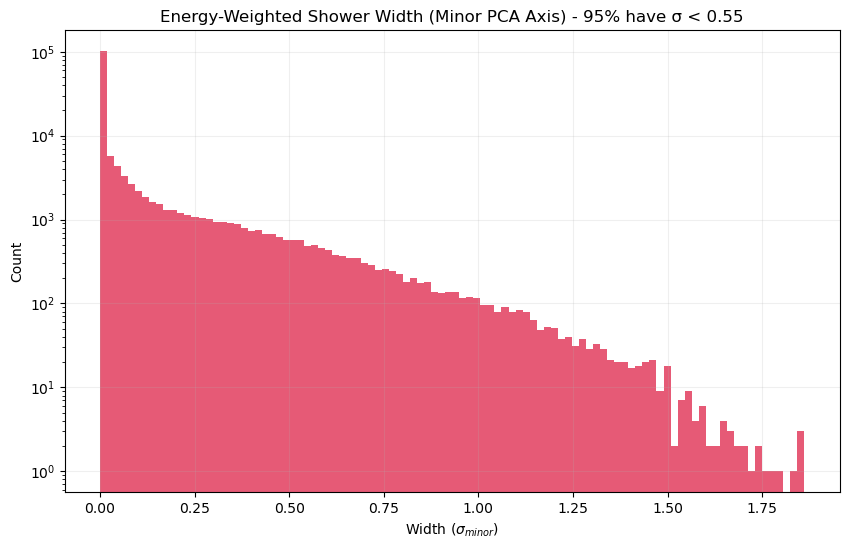

In [14]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Flatten and Filter (Standard)
# ==============================================================================
deps_flat = (
    target_particles_deps
    .explode(["particle_idx", "cluster_idx", "total_energy_deps_in_cluster"])
    .select(["event_id", "particle_idx", "cluster_idx", "total_energy_deps_in_cluster"])
    .filter(pl.col("total_energy_deps_in_cluster") >= 0.1)
)

calos_flat = (
    calos.explode(["cluster_id", "cluster_phi", "cluster_eta"])
    .select(["event_id", "cluster_id", "cluster_phi", "cluster_eta"])
)

merged = deps_flat.join(
    calos_flat,
    left_on=["event_id", "cluster_idx"],
    right_on=["event_id", "cluster_id"],
    how="inner"
)

# ==============================================================================
# 2. Weighted Centroid Calculation
# ==============================================================================
# We calculate the center of the particle using Energy as the weight (w).
# This ensures the "center" is at the heart of the high-energy deposits.
merged_with_weighted_means = merged.with_columns([
    # Weighted Mean Eta: sum(Energy * Eta) / sum(Energy)
    (
        (pl.col("cluster_eta") * pl.col("total_energy_deps_in_cluster")).sum().over(["event_id", "particle_idx"]) / 
        pl.col("total_energy_deps_in_cluster").sum().over(["event_id", "particle_idx"])
    ).alias("mean_eta_w"),

    # Weighted Vector Mean Phi: atan2( sum(w*sin), sum(w*cos) )
    pl.arctan2(
        (pl.col("cluster_phi").sin() * pl.col("total_energy_deps_in_cluster")).sum().over(["event_id", "particle_idx"]),
        (pl.col("cluster_phi").cos() * pl.col("total_energy_deps_in_cluster")).sum().over(["event_id", "particle_idx"])
    ).alias("mean_phi_w")
])

# Calculate distances from the weighted center
distances = merged_with_weighted_means.with_columns([
    (pl.col("cluster_eta") - pl.col("mean_eta_w")).alias("d_eta"),
    pl.arctan2(
        (pl.col("cluster_phi") - pl.col("mean_phi_w")).sin(),
        (pl.col("cluster_phi") - pl.col("mean_phi_w")).cos()
    ).alias("d_phi")
])

# ==============================================================================
# 3. Weighted PCA (Covariance Matrix)
# ==============================================================================
# Here, low-energy clusters at the edges count less because we multiply 
# their distance-squared by their energy.
pca_stats = distances.group_by(["event_id", "particle_idx"]).agg([
    pl.col("total_energy_deps_in_cluster").sum().alias("total_E"),
    
    # Weighted Variance Eta: Σ [ w * (eta - mean_eta)^2 ] / Σ w
    ((pl.col("d_eta").pow(2) * pl.col("total_energy_deps_in_cluster")).sum() / 
     pl.col("total_energy_deps_in_cluster").sum()).alias("var_eta"),
    
    # Weighted Variance Phi: Σ [ w * (phi - mean_phi)^2 ] / Σ w
    ((pl.col("d_phi").pow(2) * pl.col("total_energy_deps_in_cluster")).sum() / 
     pl.col("total_energy_deps_in_cluster").sum()).alias("var_phi"),
    
    # Weighted Covariance: Σ [ w * d_eta * d_phi ] / Σ w
    ((pl.col("d_eta") * pl.col("d_phi") * pl.col("total_energy_deps_in_cluster")).sum() / 
     pl.col("total_energy_deps_in_cluster").sum()).alias("cov_ep"),

    # Number of clusters for reference
    pl.len().alias("n_clusters")
])

# Solve for Eigenvalues
pca_results = pca_stats.with_columns([
    (pl.col("var_eta") + pl.col("var_phi")).alias("trace"),
    (
        (pl.col("var_eta") - pl.col("var_phi")).pow(2) + 
        4 * pl.col("cov_ep").pow(2)
    ).sqrt().alias("discriminant")
]).with_columns([
    # The Minor Axis (The "Width")
    (0.5 * (pl.col("trace") - pl.col("discriminant"))).clip(lower_bound=0.0).sqrt().alias("weighted_width"),
    # The Major Axis (The "Length")
    (0.5 * (pl.col("trace") + pl.col("discriminant"))).clip(lower_bound=0.0).sqrt().alias("weighted_length")
])

# ==============================================================================
# 4. Final Join and Analysis
# ==============================================================================
results = (
    pca_results
    .join(
        target_particles.select(["event_id", "particle_idx", "pdg_id", "energy", "pt"]).explode(["particle_idx", "pdg_id", "energy", "pt"]),
        on=["event_id", "particle_idx"],
        how="left"
    )
)

# Calculate 95th percentile for title
width_95 = np.percentile(results["weighted_width"].to_numpy(), 95)

# Plotting the Width
plt.figure(figsize=(10, 6))
plt.hist(results["weighted_width"].to_numpy(), bins=100, color='crimson', alpha=0.7)
plt.yscale('log')
plt.title(f'Energy-Weighted Shower Width (Minor PCA Axis) - 95% have σ < {width_95:.2f}')
plt.xlabel('Width ($\sigma_{minor}$)')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.show()

In [32]:
data_90[is_muon]

array([1.5794115 , 2.19459   , 0.97416764, ..., 2.642628  , 1.6222975 ,
       0.9939473 ], shape=(1424,), dtype=float32)

In [60]:
results.filter((pl.col('pdg_id')==-3122))

event_id,particle_idx,rms_delta_R,n_clusters,particle_id,pdg_id,energy,eta,phi,pt
u32,u32,f32,u32,u64,i64,f32,f32,f32,f32
916,9,0.554116,5,396,-3122,25.363159,-1.729847,2.099707,8.711768
435,31,2.500851,30,413,-3122,93.114159,2.78497,2.725662,11.451594
637,13,2.089506,5,342,-3122,13.078221,-0.359121,2.979398,12.233189
940,68,2.372975,5,1024,-3122,13.591837,-2.590472,-0.269537,2.020121
149,88,1.216298,15,981,-3122,135.394516,2.567629,0.674833,20.651945
…,…,…,…,…,…,…,…,…,…
884,33,2.012396,31,408,-3122,432.397705,-2.507082,-2.82901,70.020363
563,6,1.937518,11,396,-3122,9.994536,-2.481445,-0.776364,1.649551
134,79,2.662906,22,814,-3122,229.942383,-2.777157,2.211827,28.501141


In [ ]:
# particle_idx 37, particle_id 410 event_id 172
deps_flat = (
    target_particles_deps
    .explode(["particle_idx", "cluster_idx", "total_energy_deps_in_cluster"])
    .select([
        "event_id",
        "particle_idx",
        "cluster_idx",
        "total_energy_deps_in_cluster",
    ])
    .filter(pl.col("total_energy_deps_in_cluster") >= 0.1)
    .filter((pl.col("event_id")==172) & (pl.col("particle_idx")==37))
)
# B. Flatten Cluster Coordinates (Unchanged)
calos_flat = calos.explode(["cluster_id", "cluster_phi", "cluster_eta"]).select([
    "event_id", "cluster_id", "cluster_phi", "cluster_eta"
])

# C. Join to associate Particle -> Clusters (Unchanged)
merged = deps_flat.join(
    calos_flat,
    left_on=["event_id", "cluster_idx"],
    right_on=["event_id", "cluster_id"],
    how="inner"
)
merged

event_id,particle_idx,cluster_idx,total_energy_deps_in_cluster,cluster_phi,cluster_eta
u32,u32,u32,f64,f32,f32
172,37,2,0.379219,-1.00909,-0.286368
172,37,117,0.127118,-1.03266,-0.21353
172,37,183,0.219781,-1.057771,-0.205092
172,37,200,0.123245,2.210052,0.556318
172,37,222,0.119709,2.88484,-3.008929


In [5]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles_copy = particles.clone()

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.


In [6]:
particles = set_target_particles_maskv3(particles_copy, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.2)


Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...


/tmp/ipykernel_3672939/2599319982.py:12: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


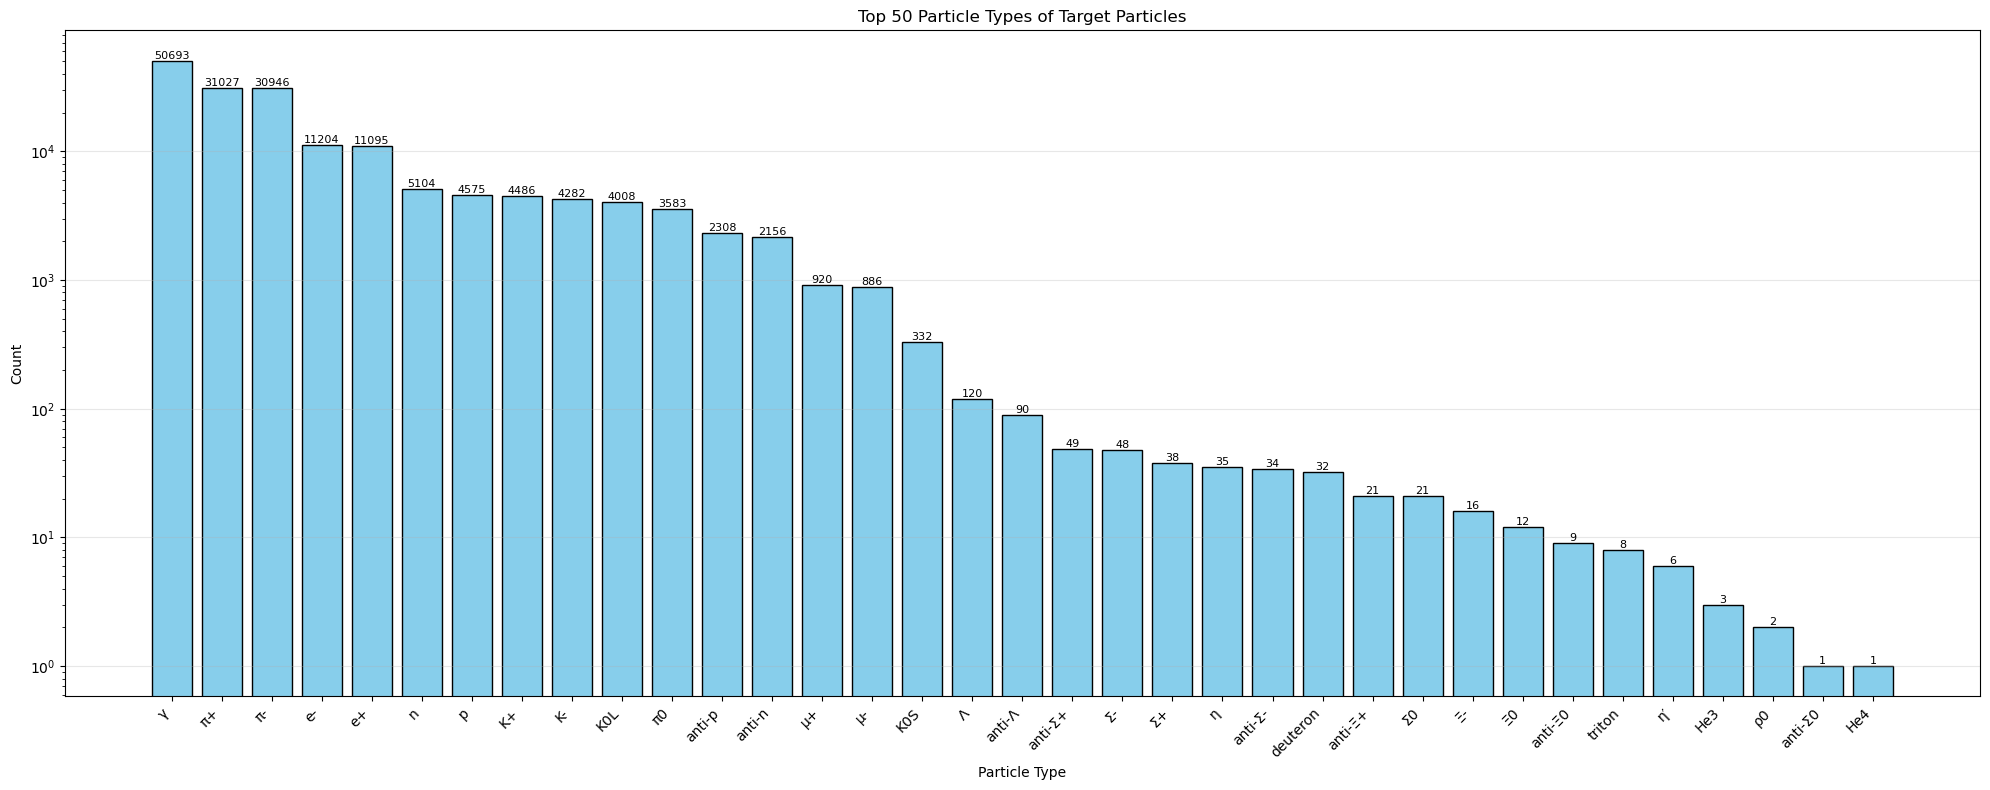

In [16]:
import matplotlib.pyplot as plt
from primary.pdg_mappings import PDG_ID_TO_NAME

# Get the PDG ID counts for target particles
pdg_counts = (
    particles.lazy()
    .select(['is_target_particle', 'pdg_id'])
    .explode('pdg_id', 'is_target_particle')
    .filter(pl.col('is_target_particle') == True)
    .select(['pdg_id'])
    .group_by('pdg_id')
    .count()
    .sort('count', descending=True)
    .head(50)
).collect()

# Map PDG IDs to names, fallback to string if not found
pdg_names = [PDG_ID_TO_NAME.get(str(pdg), str(pdg)) for pdg in pdg_counts['pdg_id']]

# Plot histogram (bar chart since PDG IDs are discrete)
plt.figure(figsize=(20, 8))  # Wider figure for better spread
bars = plt.bar(range(len(pdg_names)), pdg_counts['count'], color='skyblue', edgecolor='black', width=0.8)
plt.xlabel('Particle Type')
plt.ylabel('Count')
plt.title('Top 50 Particle Types of Target Particles')
plt.xticks(range(len(pdg_names)), pdg_names, rotation=45, ha='right')
plt.yscale('log')  # Log scale for better visibility
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars for clarity
for bar, count in zip(bars, pdg_counts['count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{count}', 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
from primary.interactive_plot import plot_3d_particle_hierarchy

plot_3d_particle_hierarchy(particles, calo_hits, event_id=435)

In [15]:
def particle_rms_analysis(results):
    import polars as pl
    import plotly.graph_objects as go
    from ipywidgets import VBox, HBox, Output
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    from primary.pdg_mappings import PDG_ID_TO_NAME  # Assuming this is available as in the example

    # 1. PREPARE DATA
    # ------------------------------------------------
    # The 'results' DataFrame already has the necessary columns: event_id, particle_idx, rms_delta_R, n_clusters, pdg_id, energy, eta, phi, pt
    # Assume it's a Polars DataFrame with these exploded/flat per particle

    combined = results.with_columns(
        pl.col("eta").abs().alias("abs_eta")
    )

    pdg_stats = (
        combined.lazy()
        .group_by("pdg_id")
        .agg([
            pl.col("rms_delta_R").mean().alias("avg_rms_delta_R"),
            pl.col("n_clusters").mean().alias("avg_n_clusters"),
            pl.col("energy").sum().alias("total_energy"),
            pl.len().alias("count")
        ])
        .filter(pl.col("count") >= 50)
        .collect()
    )

    # Prepare Bar Chart Data
    df_bar_rms = pdg_stats.sort("avg_rms_delta_R", descending=True).head(40).to_pandas()
    df_bar_rms['name'] = df_bar_rms['pdg_id'].map(lambda x: PDG_ID_TO_NAME.get(str(x), PDG_ID_TO_NAME.get(int(x), "Unknown")))
    df_bar_rms['label'] = df_bar_rms['name'] + " (" + df_bar_rms['pdg_id'].astype(str) + ")"

    df_bar_ncl = pdg_stats.sort("avg_n_clusters", descending=True).head(40).to_pandas()
    df_bar_ncl['name'] = df_bar_ncl['pdg_id'].map(lambda x: PDG_ID_TO_NAME.get(str(x), PDG_ID_TO_NAME.get(int(x), "Unknown")))
    df_bar_ncl['label'] = df_bar_ncl['name'] + " (" + df_bar_ncl['pdg_id'].astype(str) + ")"

    # 2. CREATE FIGURES
    # ------------------------------------------------
    # -- Main Bar Chart Avg RMS Delta R --
    f_bar_rms = go.FigureWidget(
        data=[go.Bar(
            x=df_bar_rms['label'], y=df_bar_rms['avg_rms_delta_R'],
            marker=dict(color=df_bar_rms['avg_rms_delta_R'], colorscale='Viridis'),
            customdata=np.stack((df_bar_rms['pdg_id'], df_bar_rms['total_energy']), axis=-1),
            hovertemplate="<b>%{x}</b><br>Avg RMS Delta R: %{y:.3f}<br>Count: %{text}<br>Total Energy: %{customdata[1]:.2e}<extra></extra>",
            text=df_bar_rms['count'],
        )],
        layout=go.Layout(title="Top 40 Highest Avg RMS Delta R", xaxis_title="Particle", yaxis_title="Avg RMS Delta R", height=400, margin=dict(l=40, r=40, t=40, b=80))
    )

    # -- Main Bar Chart Avg N Clusters --
    f_bar_ncl = go.FigureWidget(
        data=[go.Bar(
            x=df_bar_ncl['label'], y=df_bar_ncl['avg_n_clusters'],
            marker=dict(color=df_bar_ncl['avg_n_clusters'], colorscale='Viridis'),
            customdata=np.stack((df_bar_ncl['pdg_id'], df_bar_ncl['total_energy']), axis=-1),
            hovertemplate="<b>%{x}</b><br>Avg N Clusters: %{y:.3f}<br>Count: %{text}<br>Total Energy: %{customdata[1]:.2e}<extra></extra>",
            text=df_bar_ncl['count'],
        )],
        layout=go.Layout(title="Top 40 Highest Avg N Clusters", xaxis_title="Particle", yaxis_title="Avg N Clusters", height=400, margin=dict(l=40, r=40, t=40, b=80))
    )

    # -- Detail Histograms (Distributions) --
    f_rms = go.FigureWidget(
        data=[go.Histogram(x=[], name="RMS Delta R", marker_color='#636EFA', xbins=dict(start=0, size=0.01))],
        layout=go.Layout(title="RMS Delta R Distribution", height=300, margin=dict(l=40, r=40, t=40, b=40), yaxis_type='log')
    )
    f_ncl = go.FigureWidget(
        data=[go.Histogram(x=[], name="N Clusters", marker_color='#EF553B', xbins=dict(start=0, end=50, size=1))],
        layout=go.Layout(title="N Clusters Distribution", height=300, margin=dict(l=40, r=40, t=40, b=40), yaxis_type='log')
    )
    f_energy = go.FigureWidget(
        data=[go.Histogram(x=[], name="Energy", marker_color='#00CC96')],
        layout=go.Layout(title="Energy Distribution", height=300, margin=dict(l=40, r=40, t=40, b=40), yaxis_type='log')
    )
    f_pt = go.FigureWidget(
        data=[go.Histogram(x=[], name="PT", marker_color='#AB63FA')],
        layout=go.Layout(title="PT Distribution", height=300, margin=dict(l=40, r=40, t=40, b=40), yaxis_type='log')
    )
    f_eta = go.FigureWidget(
        data=[go.Histogram(x=[], name="|Eta|", marker_color='#FFA15A')],
        layout=go.Layout(title="|Eta| Distribution", height=300, margin=dict(l=40, r=40, t=40, b=40), yaxis_type='log')
    )

    # -- 2D Matplotlib Plots --
    f_rms_vs_energy = Output()
    f_rms_vs_pt = Output()
    f_rms_vs_eta = Output()

    # 3. DEFINE CLICK CALLBACK
    # ------------------------------------------------
    def update_graphs_generic(selected_pdg, particle_name):
        # Filter Data
        subset = (
            combined.lazy()
            .filter(pl.col("pdg_id") == selected_pdg)
            .select(["rms_delta_R", "n_clusters", "energy", "pt", "abs_eta"])
            .collect()
        )

        # Update Distribution Widgets
        rms_values = subset["rms_delta_R"].to_numpy()
        ncl_values = subset["n_clusters"].to_numpy()
        energy_values = subset["energy"].to_numpy()
        pt_values = subset["pt"].to_numpy()
        eta_values = subset["abs_eta"].to_numpy()

        mean_rms = np.mean(rms_values)
        mean_ncl = np.mean(ncl_values)

        f_rms.layout.title.text = f"RMS Delta R Dist: {particle_name} (Mean: {mean_rms:.3f})"
        f_ncl.layout.title.text = f"N Clusters Dist: {particle_name} (Mean: {mean_ncl:.1f})"
        f_energy.layout.title.text = f"Energy Dist: {particle_name}"
        f_pt.layout.title.text = f"PT Dist: {particle_name}"
        f_eta.layout.title.text = f"|Eta| Dist: {particle_name}"

        with f_rms.batch_animate():
            f_rms.data[0].x = rms_values
        with f_ncl.batch_animate():
            f_ncl.data[0].x = ncl_values
        with f_energy.batch_animate():
            f_energy.data[0].x = energy_values
        with f_pt.batch_animate():
            f_pt.data[0].x = pt_values
        with f_eta.batch_animate():
            f_eta.data[0].x = eta_values

        # Update 2D Histograms (Matplotlib)
        with f_rms_vs_energy:
            f_rms_vs_energy.clear_output(wait=True)
            x = energy_values
            y = rms_values
            plt.figure(figsize=(6, 5))
            h = plt.hist2d(x, y, bins=100, cmap='viridis', norm=LogNorm(), cmin=1)
            plt.colorbar(h[3], label='Count')
            plt.xscale('log')
            plt.yscale('log')
            plt.xlabel("Energy")
            plt.ylabel("RMS Delta R")
            plt.title(f"RMS vs Energy: {particle_name}")
            plt.grid(True, alpha=0.3)
            plt.show()

        with f_rms_vs_pt:
            f_rms_vs_pt.clear_output(wait=True)
            x = pt_values
            y = rms_values
            plt.figure(figsize=(6, 5))
            h = plt.hist2d(x, y, bins=100, cmap='viridis', norm=LogNorm(), cmin=1)
            plt.colorbar(h[3], label='Count')
            plt.xscale('log')
            plt.yscale('log')
            plt.xlabel("PT")
            plt.ylabel("RMS Delta R")
            plt.title(f"RMS vs PT: {particle_name}")
            plt.grid(True, alpha=0.3)
            plt.show()

        with f_rms_vs_eta:
            f_rms_vs_eta.clear_output(wait=True)
            x = eta_values
            y = rms_values
            plt.figure(figsize=(6, 5))
            h = plt.hist2d(x, y, bins=100, cmap='viridis', norm=LogNorm(), cmin=1)
            plt.colorbar(h[3], label='Count')
            plt.yscale('log')
            plt.xlabel("|Eta|")
            plt.ylabel("RMS Delta R")
            plt.title(f"RMS vs |Eta|: {particle_name}")
            plt.grid(True, alpha=0.3)
            plt.show()

    def update_graphs_rms(trace, points, selector):
        if not points.point_inds: return
        idx = points.point_inds[0]
        update_graphs_generic(trace.customdata[idx][0], df_bar_rms.iloc[idx]['name'])

    def update_graphs_ncl(trace, points, selector):
        if not points.point_inds: return
        idx = points.point_inds[0]
        update_graphs_generic(trace.customdata[idx][0], df_bar_ncl.iloc[idx]['name'])

    f_bar_rms.data[0].on_click(update_graphs_rms)
    f_bar_ncl.data[0].on_click(update_graphs_ncl)

    # 4. DISPLAY
    # ------------------------------------------------
    return VBox([
        HBox([f_bar_rms, f_bar_ncl]),
        HBox([f_rms, f_ncl]),
        HBox([f_energy, f_pt, f_eta]),
        HBox([f_rms_vs_energy, f_rms_vs_pt, f_rms_vs_eta])
    ])

particle_rms_analysis(results)

    'data': [{'customdata': array([[-3.12200000e+03,  5.01424609e…

In [94]:
results

event_id,particle_idx,rms_delta_R,n_clusters,pdg_id,energy,eta,phi,pt
u32,u32,f32,u32,i64,f32,f32,f32,f32
143,59,0.0,1,22,0.716954,-0.179285,0.930538,0.705584
720,43,0.0,1,11,4.446121,-0.266749,0.820078,4.292498
740,17,1.622029,3,-321,2.897384,0.113924,-2.062288,2.836588
920,40,0.0,1,-11,0.382927,0.007631,-2.558754,0.382916
762,14,0.0,1,211,2.016969,0.173742,0.090045,1.982143
…,…,…,…,…,…,…,…,…
140,7,2.252379,4,-211,1.25485,-0.207567,2.07457,1.220674
524,2,0.0,1,22,0.380472,0.35932,-0.823665,0.357166
633,45,0.0,1,22,0.550009,-0.153599,2.414856,0.543584


In [65]:
import polars as pl
import numpy as np

# A. Flatten Particle Dependencies (Unchanged)
deps_flat = target_particles_deps.explode(["particle_idx", "cluster_idx"]).select([
    "event_id", "particle_idx", "cluster_idx"
])

# B. Flatten Cluster Coordinates (Unchanged)
calos_flat = calos.explode(["cluster_id", "cluster_phi", "cluster_eta"]).select([
    "event_id", "cluster_id", "cluster_phi", "cluster_eta"
])

# C. Join to associate Particle -> Clusters (Unchanged)
merged = deps_flat.join(
    calos_flat,
    left_on=["event_id", "cluster_idx"],
    right_on=["event_id", "cluster_id"],
    how="inner"
)

# D. Calculate Centroid (Mean Eta, Vector Mean Phi) per Particle (Unchanged)
merged_with_means = merged.with_columns([
    pl.col("cluster_eta").mean().over(["event_id", "particle_idx"]).alias("mean_eta"),
    pl.arctan2(
        pl.col("cluster_phi").sin().sum().over(["event_id", "particle_idx"]),
        pl.col("cluster_phi").cos().sum().over(["event_id", "particle_idx"])
    ).alias("mean_phi")
])

# ==============================================================================
# E. Calculate Distance (Delta R) from Centroid
#    UPDATED: Using arctan2(sin(diff), cos(diff)) to handle angular wrapping
# ==============================================================================
distances = merged_with_means.with_columns([
    (pl.col("cluster_eta") - pl.col("mean_eta")).alias("d_eta"),
    
    # We calculate the raw difference, then take sin/cos, then arctan2.
    # This guarantees the result is between -pi and +pi.
    pl.arctan2(
        (pl.col("cluster_phi") - pl.col("mean_phi")).sin(),
        (pl.col("cluster_phi") - pl.col("mean_phi")).cos()
    ).alias("d_phi")
]).with_columns([
    # Squared Delta R
    (pl.col("d_eta").pow(2) + pl.col("d_phi").pow(2)).alias("delta_R_sq")
])

# F. Aggregate: Calculate RMS per particle (Unchanged)
result_lazy = distances.group_by(["event_id", "particle_idx"]).agg([
    (pl.col("delta_R_sq").mean()).sqrt().fill_null(0.0).alias("rms_delta_R"),
    pl.len().alias("n_clusters")
])

In [ ]:
# Check if any particle has multiple tracks
particles_with_multiple_tracks = (
    tracks.lazy()
    .select(['event_id', 'majority_particle_id', 'track_id'])
    .explode(['majority_particle_id', 'track_id'])
    .group_by('majority_particle_id')
    .agg(pl.col('track_id').n_unique().alias('num_tracks'))
    .filter(pl.col('num_tracks') > 1)
    .collect()
)

if particles_with_multiple_tracks.height > 0:
    print(f"Found {particles_with_multiple_tracks.height} particles with multiple tracks.")
    print(particles_with_multiple_tracks.head())
else:
    print("No particles have multiple tracks.")

In [18]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv3
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles_copy = particles.clone()



Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 11 iterations on 20291528 depositors.


In [8]:
particles = set_target_particles_maskv3(particles_copy, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=1.0)
particles

Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...


event_id,is_target_particle,is_truth_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
393,"[true, true, … false]","[true, true, … false]","[false, true, … false]","[true, true, … false]","[65, 66, … 6797]","[-211, 211, … 2212]","[0.13957, 0.13957, … 0.938272]","[8.791349, 3.546382, … 1.217234]","[-1.0, 1.0, … 1.0]","[-0.002553, -0.002553, … 1541.634399]","[-0.00393, -0.00393, … 961.824402]","[43.09972, 43.09972, … 27.119455]","[0.018686, 0.018686, … 6.474351]","[8.038111, 3.383335, … -0.137164]","[3.534456, 0.903935, … 0.680441]","[0.405885, -0.541562, … 0.345674]","[-0.00257, -0.003138, … -1701.298462]","[43.099899, 43.099182, … -290.713501]","[1, 1, … 1]","[7, 7, … 6790]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[0.046207, -0.154033, … 0.479421]","[0.414266, 0.261075, … 1.769712]","[8.780866, 3.502007, … 0.694128]"
262,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[73, 74, … 6085]","[221, 111, … 22]","[0.54785, 0.13498, … 0.0]","[925.723267, 250.903564, … 122.575623]","[0.0, 0.0, … 0.0]","[-0.002603, -0.002603, … -0.002584]","[0.016753, 0.016753, … 0.016759]","[-86.004395, -86.004395, … -86.046112]","[0.160169, 0.160169, … 0.160308]","[0.299144, -0.172326, … -0.003187]","[-0.127591, 0.118667, … 0.015317]","[-925.723022, -250.903442, … -122.575623]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[1, 1, … 1]","[8, 8, … 204]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[-8.6469, -7.782544, … -9.658937]","[-0.403159, 2.538546, … 1.775919]","[0.325218, 0.209232, … 0.015645]"
652,"[false, true, … false]","[false, true, … false]","[false, true, … false]","[false, false, … false]","[57, 58, … 5277]","[-313, -211, … 11]","[0.908738, 0.13957, … 0.000511]","[4.229085, 11.952354, … 0.00052]","[0.0, -1.0, … -1.0]","[0.005982, 0.005982, … 194.004669]","[0.001853, 0.001853, … 494.204834]","[-21.549875, -21.549875, … 1557.38562]","[0.064334, 0.064334, … 6.291512]","[-0.07758, 0.659941, … -0.00009]","[-0.338812, 1.110471, … -0.000028]","[4.115646, 11.881525, … -0.000003]","[0.005418, -0.004196, … NaN]","[-21.512682, -21.592632, … NaN]","[1, 1, … 1]","[7, 7, … 5276]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[3.16648, 2.915061, … -0.033526]","[-1.795892, 1.034586, … -2.837505]","[0.347581, 1.29177, … 0.000094]"
128,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[72, 73, … 5745]","[-211, 111, … 22]","[0.13957, 0.13498, … 0.0]","[14.697523, 28.742641, … 10.422291]","[-1.0, 0.0, … 0.0]","[0.008799, 0.008799, … 0.008619]","[0.012207, 0.012207, … 0.011928]","[-19.32469, -19.32469, … -19.313713]","[-0.047147, -0.047147, … -0.047111]","[0.515557, -0.469452, … -0.170177]","[-0.546971, -0.728459, … -0.329013]","[14.677627, 28.729256, … 10.415706]","[0.014775, 0.000784, … 0.002176]","[-19.269085, -18.826542, … -18.904451]","[1, 1, … 1]","[8, 8, … 73]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[3.665613, 4.194441, … 4.0299]","[-0.814955, -2.143257, … -2.048136]","[0.751649, 0.866624, … 0.370419]"
387,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[false, false, … false]","[104, 105, … 9594]","[213, -211, … 22]","[0.735179, 0.13957, … 0.0]","[118.035141, 49.929668, … 9.478293]","[1.0, -1.0, … 0.0]","[-0.018042, -0.018042, … 24.540348]","[0.018347, 0.018347, … 44.978424]","[92.717186, 92.717186, … -1320.670776]","[0.010941, 0.010941, … 4.728593]","[1.726296, 0.712598, … 0.152364

In [37]:
# apply to truth 1 Gev

(particles.lazy()
 .select(['event_id','particle_id','is_target_particle', 'pdg_id', 'enter_calo', 'has_track','created_inside_calo'])
 .explode('particle_id','pdg_id', 'is_target_particle', 'enter_calo', 'has_track', 'created_inside_calo')
 .filter(pl.col('is_target_particle')==True)
 .filter(pl.col('pdg_id')==111)
 .join(
     (particles.lazy()
      .select(['event_id','particle_id','parent_id','is_target_particle', 'pdg_id', 'enter_calo', 'has_track','created_inside_calo'])
      .explode('particle_id','pdg_id', 'parent_id', 'is_target_particle', 'enter_calo', 'has_track', 'created_inside_calo')
     ),
     left_on=['event_id', 'particle_id'],
     right_on=['event_id', 'parent_id'],
     suffix='_child'
 )
.join( (
        calo_hits.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
        .with_columns(pl.lit(True).alias('has_calo_hit'))
        ),
        on=['event_id', 'particle_id'],how='left')

).collect()

event_id,particle_id,is_target_particle,pdg_id,enter_calo,has_track,created_inside_calo,particle_id_child,is_target_particle_child,pdg_id_child,enter_calo_child,has_track_child,created_inside_calo_child,has_calo_hit
u32,u64,bool,i64,bool,bool,bool,u64,bool,i64,bool,bool,bool,bool
393,892,true,111,true,false,false,1378,false,22,true,false,false,true
262,756,true,111,true,false,false,1956,false,22,true,false,false,true
262,872,true,111,true,false,false,4440,false,22,true,false,false,true
262,419,true,111,true,false,false,4678,false,22,false,false,false,true
128,734,true,111,true,false,false,1488,false,-11,true,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…
708,153,true,111,true,false,false,7114,false,22,false,false,true,true
970,401,true,111,true,false,false,2566,false,22,true,false,false,true
720,252,true,111,true,false,false,1804,false,22,true,false,false,true


In [36]:
 (
        calo_hits.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
    ).collect().filter((pl.col('event_id')==1) & (pl.col('particle_id')==351))

event_id,particle_id
u32,i64
1,351


In [ ]:
from primary.preprocessing import map_calo_depositors_to_first_outside_ancestor
res = map_calo_depositors_to_first_outside_ancestor(particles, calo_hits)
res

Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.


event_id,particle_id,ancestor_outside_calo_id
u32,i64,i64
977,2581,2563
977,2612,2563
977,2648,2563
977,2654,2563
977,2666,2563
…,…,…
85,1346,1343
85,1353,1343
85,1373,1343


In [ ]:
(
        calo_hits.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
        .filter((pl.col('particle_id') == 2563) & (pl.col('event_id') == 977))
    ).collect()

event_id,particle_id
u32,i64


In [ ]:
(res.lazy()
 .join(
     particles.lazy().select(['event_id', 'particle_id', 'pdg_id', 'is_target_particle', 'enter_calo', 'has_track', 'created_inside_calo'])
     .explode('particle_id', 'pdg_id', 'is_target_particle', 'enter_calo', 'has_track', 'created_inside_calo')
     ,
     left_on=['event_id', 'ancestor_outside_calo_id'],
     right_on=['event_id', 'particle_id'],

 )
 .filter((pl.col('is_target_particle')==True) & (pl.col('pdg_id')==111))
 ).collect()

event_id,particle_id,ancestor_outside_calo_id,pdg_id,is_target_particle,enter_calo,has_track,created_inside_calo
u32,i64,i64,i64,bool,bool,bool,bool
182,526,526,111,true,true,false,false
843,540,540,111,true,true,false,false
453,474,474,111,true,true,false,false
706,472,472,111,true,true,false,false
837,168,168,111,true,true,false,false
…,…,…,…,…,…,…,…
880,333,333,111,true,true,false,false
874,390,390,111,true,true,false,false
228,790,790,111,true,true,false,false


In [12]:
from primary.interactive_plot import plot_3d_particle_hierarchy
plot_3d_particle_hierarchy(particles, calo_hits=calo_hits, event_id=393)

In [20]:
from primary.interactive_plot import target_vs_truth_particles
target_vs_truth_particles(particles)

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


    'data': [{'customdata': array([[-1.50000000e+01,  5.07858281e+04],
         …

event_id,ht_target,ht_truth
u32,f32,f32
2281,722.501404,738.680664
4930,558.053345,615.365967
1696,741.123108,729.020813
4968,541.454163,541.71759
3553,1647.14978,1648.515625
…,…,…
454,312.334778,339.037445
1597,518.335693,525.02301
370,365.694672,378.381195


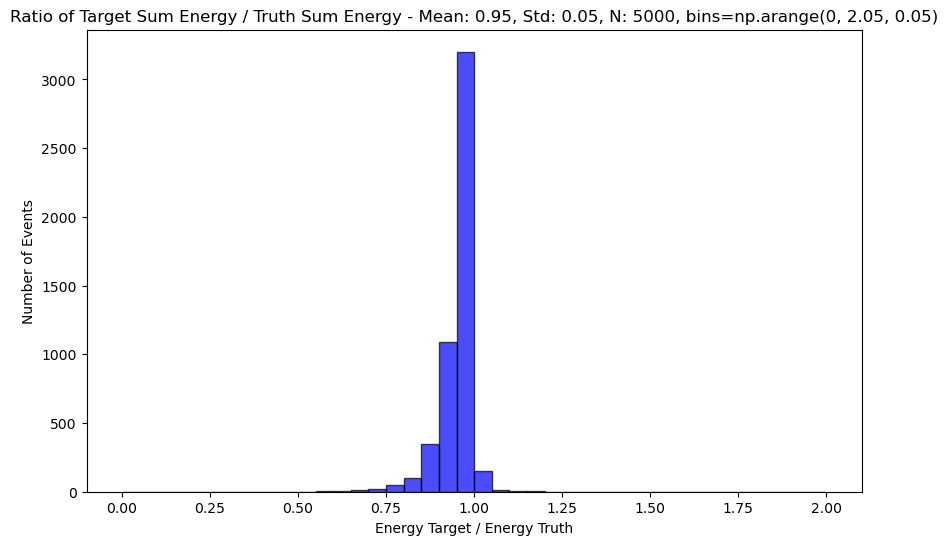

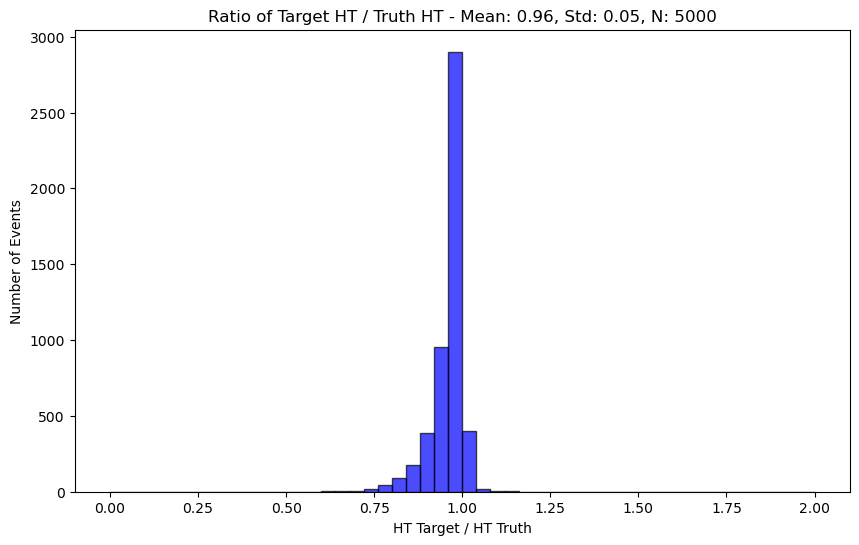

In [21]:
from primary.plot import histogram_ht_ratio,hist2d_ht_truth_vs_target, histogram_energy_ratio
histogram_energy_ratio(particles)
histogram_ht_ratio(particles)

Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


event_id,ht_target,ht_truth
u32,f32,f32
3587,910.51123,939.527527
3270,478.01355,487.496429
525,670.116028,671.292236
2619,263.914337,268.950195
3241,695.540466,713.043884
…,…,…
566,391.190247,398.302307
821,608.277161,654.863708
2140,386.330719,405.769928


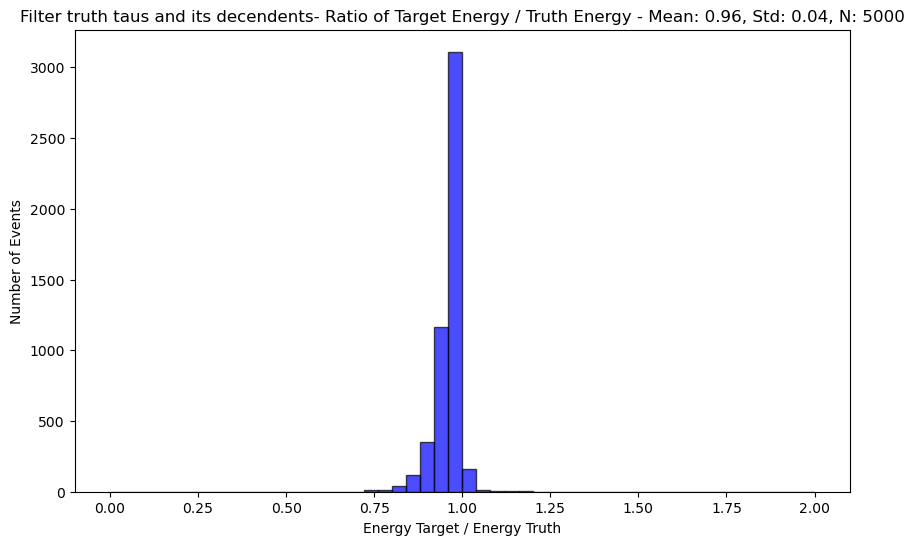

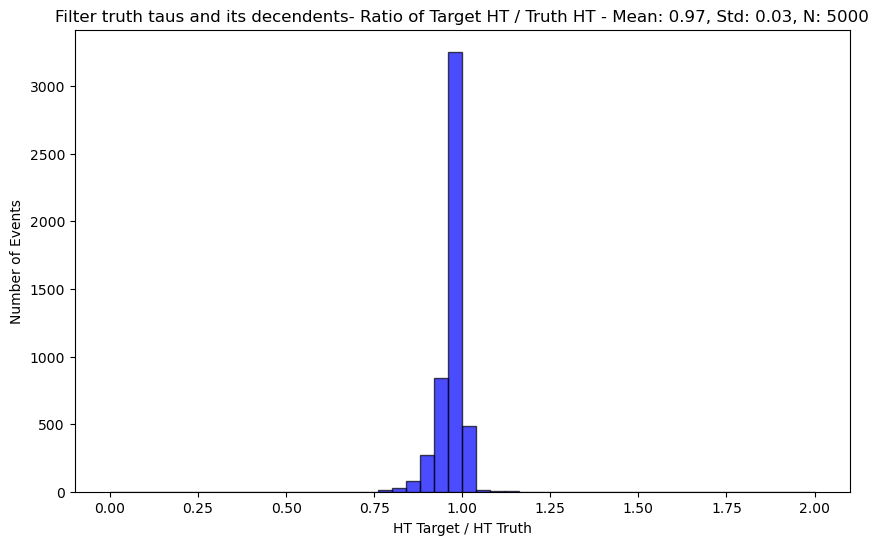

In [22]:
from primary.plot import histogram_ht_filter_taus, histogram_energy_filter_taus
histogram_energy_filter_taus(particles)
histogram_ht_filter_taus(particles)

event_id,ht_target,ht_truth
u32,f32,f32
4886,367.461884,421.719818
1293,211.550247,307.66333
139,356.166016,383.847748
1883,385.194092,444.342255
1775,247.166504,343.074768
…,…,…
2668,466.191071,512.499512
2237,173.063416,205.88269
4497,344.94162,394.723206


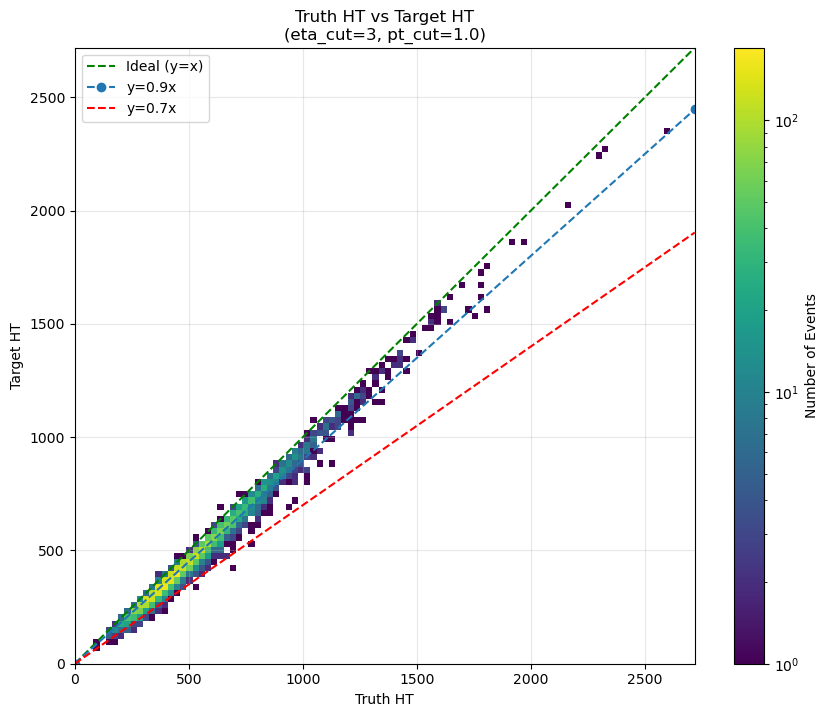

In [20]:
hist2d_ht_truth_vs_target(particles,eta_cut=3, pt_cut=1.0)

In [28]:
# calo clusters cutoff plots
from primary.plot import plot_calo_cluster_cutoff_plots
from primary.preprocessing import add_ms_cluster_labels
calo_hits = add_ms_cluster_labels(calo_hits, bandwidth=120.0)


--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 4000 events. Time: 2.59s
Workload optimized: 4000 events merged into 4000 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 1045.54s


In [33]:
from primary.create_trainning_dataset import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, tracks=tracks, calo_hits=calo_hits, num_of_events=1000, truth_pt_cut=1, truth_eta_cut=3.0,
                                    target_pt_cut=0.3, clusters_cutoff=0.23)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 7 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 1000 events. Time: 0.71s
Workload optimized: 1000 events merged into 1000 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 267.96s
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from 

In [34]:
df_deps=preprocessed['target_particles_deps']
df_particles=preprocessed['target_particles']
df_clusters=preprocessed['calo_clusters']
df_tracks=preprocessed['tracks']

In [35]:
df_clusters

event_id,cluster_id,total_cluster_energy,hcal_energy,sigma_eta,sigma_phi,sigma_rho,cluster_phi,cluster_eta,cluster_rho,hcal_fraction
u32,list[i32],list[f64],list[f64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f64]
0,"[0, 1, … 301]","[117.038543, 13.86953, … 0.245044]","[0.0, 0.0, … 0.245044]","[0.01673, 0.036442, … 0.0]","[0.022366, 0.028642, … 0.0]","[27.062729, 55.675186, … 0.0]","[-1.505896, 0.874787, … -1.857073]","[1.687719, -0.214194, … 2.166135]","[1265.896118, 1344.90979, … 847.282654]","[0.0, 0.0, … 1.0]"
1,"[0, 1, … 368]","[127.071303, 65.037671, … 0.811319]","[0.0, 0.0, … 0.0]","[0.016922, 0.042009, … 0.0]","[0.021009, 0.060175, … 0.0]","[34.49913, 40.156582, … 0.0]","[-1.781798, -1.043302, … 1.841474]","[-1.10054, -2.008766, … -1.231915]","[1332.636353, 900.028076, … 1424.592529]","[0.0, 0.0, … 0.0]"
2,"[0, 1, … 576]","[59.975367, 47.772519, … 0.819313]","[0.0, 0.0, … 0.819313]","[0.024936, 0.032155, … 0.0]","[0.40881, 0.038473, … 0.0]","[43.255806, 44.214653, … 0.0]","[3.057412, -2.035884, … -2.068882]","[0.244793, -1.473731, … -1.248928]","[1334.866089, 1357.624756, … 2566.729736]","[0.0, 0.0, … 1.0]"
3,"[0, 1, … 700]","[48.13458, 45.11502, … 0.427596]","[0.0, 0.0, … 0.427596]","[0.039802, 0.027216, … 0.018499]","[0.047512, 0.052917, … 0.030104]","[59.174438, 43.704994, … 63.050285]","[2.182628, -0.409989, … -2.668055]","[0.307553, -0.241523, … 0.991946]","[1366.6521, 1342.675171, … 1857.566162]","[0.0, 0.0, … 1.0]"
4,"[0, 1, … 482]","[46.673636, 14.84895, … 1.176899]","[0.0, 0.0, … 1.176899]","[0.021042, 0.021785, … 0.0]","[0.044711, 0.022532, … 0.0]","[55.661095, 50.291481, … 0.0]","[-0.575668, 1.02751, … 3.058474]","[0.755694, 0.559448, … 0.099463]","[1341.952271, 1368.279297, … 1806.737427]","[0.0, 0.0, … 1.0]"
…,…,…,…,…,…,…,…,…,…,…
995,"[0, 1, … 909]","[178.899145, 53.078415, … 0.311949]","[0.0, 0.0, … 0.311949]","[0.043587, 0.036794, … 0.022058]","[0.050596, 0.041631, … 0.03268]","[63.85331, 50.812042, … 68.766045]","[-0.340856, 2.486166, … -2.823586]","[0.673893, -0.602709, … 0.059663]","[1402.301025, 1356.122559, … 2010.104614]","[0.0, 0.0, … 1.0]"
996,"[0, 1, … 949]","[160.598688, 105.315553, … 0.838095]","[0.0, 0.0, … 0.838095]","[0.07089, 0.038415, … 0.0]","[0.147197, 0.055058, … 0.0]","[27.07921, 38.834797, … 0.0]","[0.843383, 1.620259, … 2.954425]","[-2.875715, -1.918133, … -1.564991]","[377.04306, 990.042542, … 1773.46228]","[0.0, 0.0, … 1.0]"
997,"[0, 1, … 988]","[818.562793, 42.76936, … 0.348223]","[0.0, 0.0, … 0.348223]","[0.056181, 0.12039, … 0.033317]","[0.061527, 0.054964, … 0.014744]","[37.325344, 82.404259, … 71.48912]","[-1.99094, 1.939214, … -2.833102]","[2.38528, 2.347461, … -1.350298]","[621.861267, 643.106812, … 2140.07251]","[0.0, 0.0, … 1.0]"


In [9]:
# ...existing code...
# 1. Flatten particles and create a local index (0 to N-1) to match df_deps format
flat_particles = (
    df_particles.lazy()
    .select(["event_id", "particle_id", "pdg_id", "has_track", "energy", "pt"])
    .with_columns(
        particle_idx=pl.int_ranges(0, pl.col("particle_id").list.len())
    )
    .explode(["particle_id", "pdg_id", "has_track", "energy", "pt", "particle_idx"])
)

# 2. Get the set of particle indices that HAVE energy deposits
particles_with_deps = (
    df_deps.lazy()
    .select(["event_id", "particle_idx"])
    .explode("particle_idx")
    .unique()
    .with_columns(has_deps=pl.lit(True))
)

# 3. Join and find the "Ghosts" (No Track AND No Deps)
ghost_particles = (
    flat_particles.join(
        particles_with_deps, on=["event_id", "particle_idx"], how="left"
    )
    .with_columns(pl.col("has_deps").fill_null(False))
    .filter((~pl.col("has_track")) & (~pl.col("has_deps")))
    .collect()
)

# 4. Report results
num_ghosts = ghost_particles.height
print(f"Found {num_ghosts} particles with NO track and NO energy deposits.")

if num_ghosts > 0:
    print("\nSample of Ghost Particles:")
    print(ghost_particles.sort('pt', descending=True).head(10))

    print("\nBreakdown by PDG ID (Likely Neutrinos?):")
    print(
        ghost_particles.group_by("pdg_id")
        .agg(pl.count("event_id").alias("count")))
        # filepath: /storage/agrp/barakma/PileupODD/run_preprocessing.ipynb
# ...existing code...
# 4. Report results
num_ghosts = ghost_particles.height
print(f"Found {num_ghosts} particles with NO track and NO energy deposits.")

if num_ghosts > 0:
    print("\nSample of Ghost Particles:")
    print(ghost_particles.head(10))

    print("\nBreakdown by PDG ID (Likely Neutrinos?):")
    print(
        ghost_particles.group_by("pdg_id")
        .agg(pl.count("event_id").alias("count"))
        .sort("count", descending=True)
    )

Found 0 particles with NO track and NO energy deposits.
Found 0 particles with NO track and NO energy deposits.


In [19]:
particles.select('pdg_id').explode("pdg_id").filter(pl.col('pdg_id')==-999).count()

pdg_id
u32
0


In [10]:
# Verify that all particle_idx in deps refer to valid particles
# Join deps with particles to compare max index with length
invalid_indices = (
    df_tracks.lazy()
    .select(["event_id", "particle_idx"])
    .join(
        df_particles.lazy().select(
            pl.col("event_id"), 
            pl.col("particle_id").list.len().alias("num_particles")
        ),
        on="event_id"
    )
    .with_columns(
        pl.col("particle_idx").list.max().alias("max_referenced_idx")
    )
    .filter(
        pl.col("max_referenced_idx") >= pl.col("num_particles")
    )
    .collect()
)

if invalid_indices.height == 0:
    print("✅ All particle indices in deps are valid!")
else:
    print(f"❌ Found {invalid_indices.height} events with invalid indices:")
    print(invalid_indices)

✅ All particle indices in deps are valid!


In [11]:
def check_list_lengths(df, name):
    print(f"Checking {name}...")
    # Get columns that are of List type
    list_cols = [col for col, dtype in df.schema.items() if isinstance(dtype, pl.List)]
    
    if not list_cols:
        print(f"  No list columns found in {name}")
        return

    # Create expressions to get length of each list column
    length_exprs = [pl.col(c).list.len().alias(f"{c}_len") for c in list_cols]
    
    # Check if all lengths are equal 
    validity_check = df.lazy().select(
        pl.col("event_id"),
        (pl.min_horizontal(length_exprs) == pl.max_horizontal(length_exprs)).alias("is_consistent")
    ).filter(~pl.col("is_consistent")).collect()
    
    if validity_check.height == 0:
        print(f"  ✅ All list columns in {name} have consistent lengths per event.")
    else:
        print(f"  ❌ Found {validity_check.height} inconsistent events in {name}!")
        print(validity_check.head())
        # To debug which columns mismatch, we can print the lengths for the bad rows
        bad_ids = validity_check["event_id"]
        print("  Bad row lengths details:")
        print(df.filter(pl.col("event_id").is_in(bad_ids)).select(["event_id"] + length_exprs).head())

# Run checks
dfs_to_check = {
    "target_particles": df_particles,
    "calo_clusters": df_clusters,
    "tracks": df_tracks,
    "target_particles_deps": df_deps
}

for name, df in dfs_to_check.items():
    check_list_lengths(df, name)

Checking target_particles...
  ✅ All list columns in target_particles have consistent lengths per event.
Checking calo_clusters...
  ✅ All list columns in calo_clusters have consistent lengths per event.
Checking tracks...
  ✅ All list columns in tracks have consistent lengths per event.
Checking target_particles_deps...
  ✅ All list columns in target_particles_deps have consistent lengths per event.


In [23]:
df_clusters

event_id,cluster_id,total_cluster_energy,hcal_energy,sigma_eta,sigma_phi,sigma_rho,cluster_phi,cluster_eta,cluster_rho,hcal_fraction
u32,list[i32],list[f64],list[f64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f64]
0,"[0, 1, … 291]","[117.038543, 13.86953, … 0.58137]","[0.0, 0.0, … 0.58137]","[0.01673, 0.036442, … 0.05332]","[0.022366, 0.028642, … 0.176542]","[27.062729, 55.675186, … 14.357333]","[-1.505896, 0.874787, … -1.406761]","[1.687719, -0.214194, … 3.168979]","[1265.896118, 1344.90979, … 367.421204]","[0.0, 0.0, … 1.0]"
1,"[0, 1, … 368]","[127.071303, 65.037671, … 0.811319]","[0.0, 0.0, … 0.0]","[0.016922, 0.042009, … 0.0]","[0.021009, 0.060175, … 0.0]","[34.49913, 40.156582, … 0.0]","[-1.781798, -1.043302, … 1.841474]","[-1.10054, -2.008766, … -1.231915]","[1332.636353, 900.028076, … 1424.592529]","[0.0, 0.0, … 0.0]"
2,"[0, 1, … 576]","[59.975367, 47.772519, … 0.819313]","[0.0, 0.0, … 0.819313]","[0.024936, 0.032155, … 0.0]","[0.40881, 0.038473, … 0.0]","[43.255806, 44.214653, … 0.0]","[3.057412, -2.035884, … -2.068882]","[0.244793, -1.473731, … -1.248928]","[1334.866089, 1357.624756, … 2566.729736]","[0.0, 0.0, … 1.0]"
3,"[0, 1, … 700]","[48.13458, 45.11502, … 0.427596]","[0.0, 0.0, … 0.427596]","[0.039802, 0.027216, … 0.018499]","[0.047512, 0.052917, … 0.030104]","[59.174438, 43.704994, … 63.050285]","[2.182628, -0.409989, … -2.668055]","[0.307553, -0.241523, … 0.991946]","[1366.6521, 1342.675171, … 1857.566162]","[0.0, 0.0, … 1.0]"
4,"[0, 1, … 482]","[46.673636, 14.84895, … 1.176899]","[0.0, 0.0, … 1.176899]","[0.021042, 0.021785, … 0.0]","[0.044711, 0.022532, … 0.0]","[55.661095, 50.291481, … 0.0]","[-0.575668, 1.02751, … 3.058474]","[0.755694, 0.559448, … 0.099463]","[1341.952271, 1368.279297, … 1806.737427]","[0.0, 0.0, … 1.0]"
…,…,…,…,…,…,…,…,…,…,…
995,"[0, 1, … 909]","[178.899145, 53.078415, … 0.311949]","[0.0, 0.0, … 0.311949]","[0.043587, 0.036794, … 0.022058]","[0.050596, 0.041631, … 0.03268]","[63.85331, 50.812042, … 68.766045]","[-0.340856, 2.486166, … -2.823586]","[0.673893, -0.602709, … 0.059663]","[1402.301025, 1356.122559, … 2010.104614]","[0.0, 0.0, … 1.0]"
996,"[0, 1, … 949]","[160.598688, 105.315553, … 0.838095]","[0.0, 0.0, … 0.838095]","[0.07089, 0.038415, … 0.0]","[0.147197, 0.055058, … 0.0]","[27.07921, 38.834797, … 0.0]","[0.843383, 1.620259, … 2.954425]","[-2.875715, -1.918133, … -1.564991]","[377.04306, 990.042542, … 1773.46228]","[0.0, 0.0, … 1.0]"
997,"[0, 1, … 988]","[818.562793, 42.76936, … 0.348223]","[0.0, 0.0, … 0.348223]","[0.056181, 0.12039, … 0.033317]","[0.061527, 0.054964, … 0.014744]","[37.325344, 82.404259, … 71.48912]","[-1.99094, 1.939214, … -2.833102]","[2.38528, 2.347461, … -1.350298]","[621.861267, 643.106812, … 2140.07251]","[0.0, 0.0, … 1.0]"


In [32]:
df_tracks[0].select(pl.col("particle_idx").explode()).to_series().to_torch()

tensor([ 5,  0,  1,  2, 17,  8, 14, 18, 13, 15, 20, 19, 16,  7,  4,  3,  6])

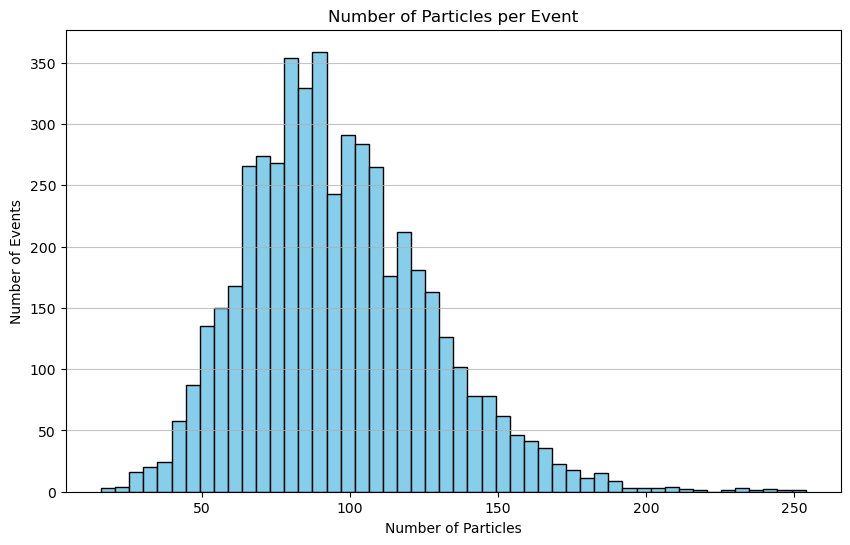

In [37]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = (
    particles.lazy()
    .select('event_id', 'particle_id', 'is_target_particle')
    .explode('particle_id', 'is_target_particle')
    .filter('is_target_particle')
    .group_by('event_id')
    .agg(pl.col('particle_id').count().alias('num_particles'))
    .collect()
)

plt.figure(figsize=(10, 6))
plt.hist(n_particles['num_particles'], bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

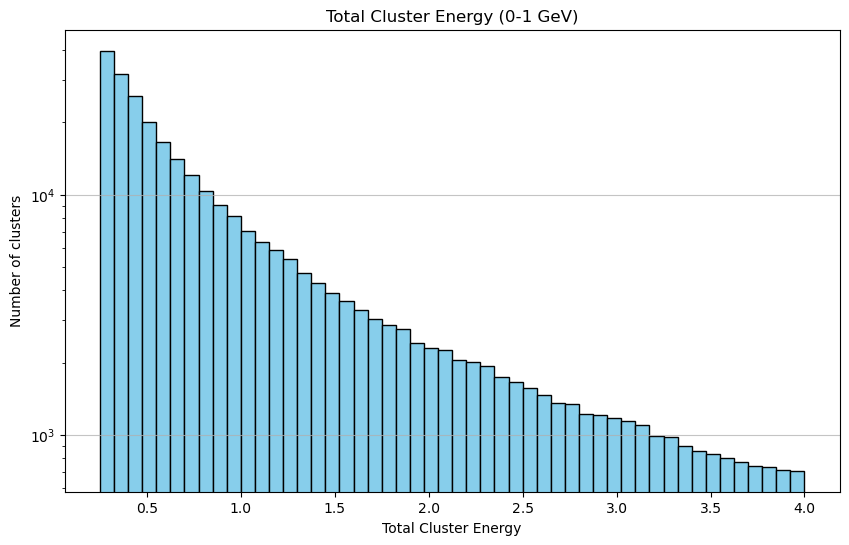

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate number of particles per event from target_particles
n_particles = df_clusters.select(pl.col("total_cluster_energy")).explode("total_cluster_energy").to_series().to_numpy()

# Filter to only show values between 0 and 1
n_particles_filtered = n_particles[(n_particles >= 0.001) & (n_particles <= 4)]

plt.figure(figsize=(10, 6))
plt.hist(n_particles_filtered, bins=50, color='skyblue', edgecolor='black')
plt.title('Total Cluster Energy (0-1 GeV)')
plt.xlabel('Total Cluster Energy')
plt.ylabel('Number of clusters')
plt.grid(axis='y', alpha=0.75)
# log scale for y-axis
plt.yscale('log')
plt.show()


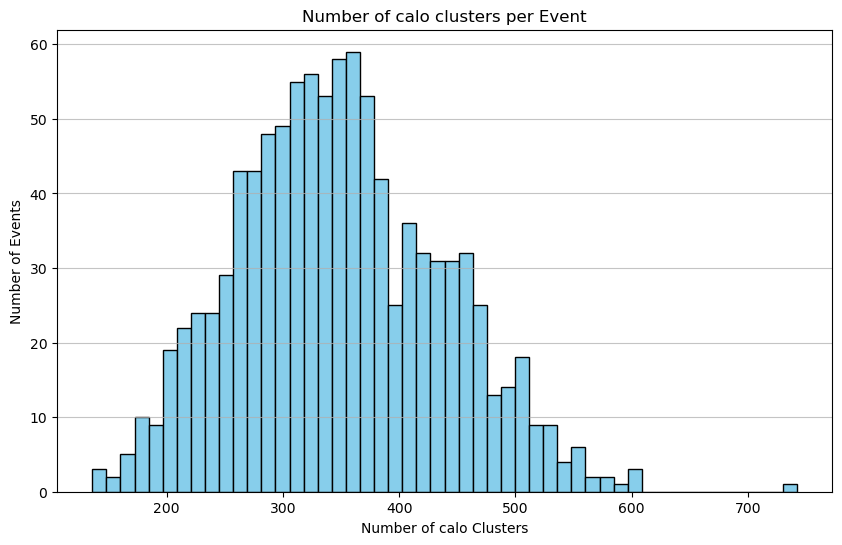

In [32]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = df_clusters["cluster_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of calo clusters per Event')
plt.xlabel('Number of calo Clusters')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

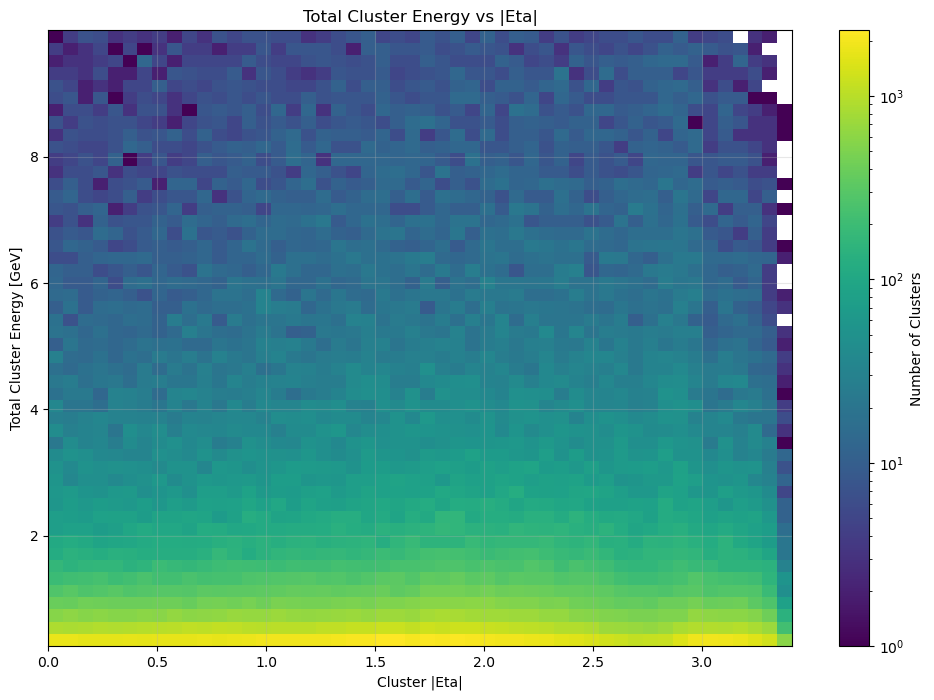

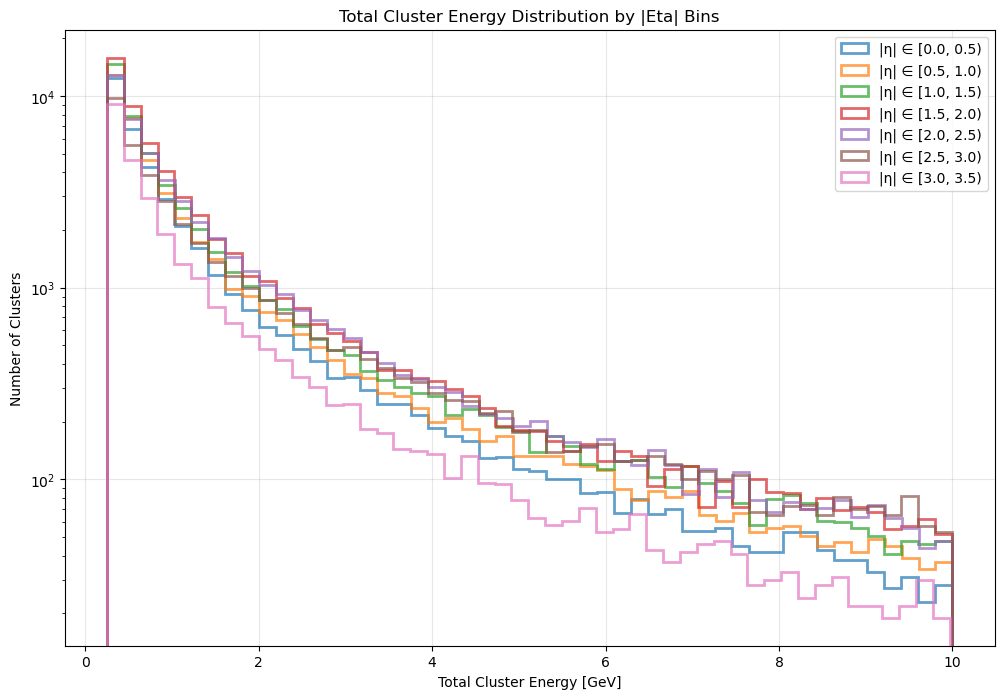

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Explode the lists to get individual cluster data
exploded_clusters = df_clusters.select([
    pl.col("event_id"),
    pl.col("cluster_id"),
    pl.col("total_cluster_energy"),
    pl.col("cluster_eta"),
    pl.col("cluster_phi")
]).explode(['cluster_id', 'total_cluster_energy', 'cluster_eta', 'cluster_phi'])

# Convert to numpy arrays for plotting
energies = exploded_clusters["total_cluster_energy"].to_numpy()
etas = exploded_clusters["cluster_eta"].to_numpy()

# Filter for reasonable energy range (0.001 to 10 GeV) and eta range (-4 to 4)
mask = (energies >= 0.001) & (energies <= 10) & (etas >= -4) & (etas <= 4)
energies_filtered = energies[mask]
etas_filtered = np.abs(etas[mask])  # Use absolute value of eta

# Create 2D histogram of energy vs |eta|
plt.figure(figsize=(12, 8))
plt.hist2d(etas_filtered, energies_filtered, bins=(50, 50), cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(label='Number of Clusters')
plt.title('Total Cluster Energy vs |Eta|')
plt.xlabel('Cluster |Eta|')
plt.ylabel('Total Cluster Energy [GeV]')
plt.grid(True, alpha=0.3)
plt.show()

# Alternative: Histogram of energy for different |eta| bins
eta_bins = np.linspace(0, 4, 9)  # 8 bins from 0 to 4 for |eta|
plt.figure(figsize=(12, 8))

for i in range(len(eta_bins)-1):
    eta_mask = (etas_filtered >= eta_bins[i]) & (etas_filtered < eta_bins[i+1])
    energies_in_bin = energies_filtered[eta_mask]
    
    if len(energies_in_bin) > 0:
        plt.hist(energies_in_bin, bins=50, alpha=0.7, 
                label=f'|η| ∈ [{eta_bins[i]:.1f}, {eta_bins[i+1]:.1f})', 
                histtype='step', linewidth=2)

plt.title('Total Cluster Energy Distribution by |Eta| Bins')
plt.xlabel('Total Cluster Energy [GeV]')
plt.ylabel('Number of Clusters')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

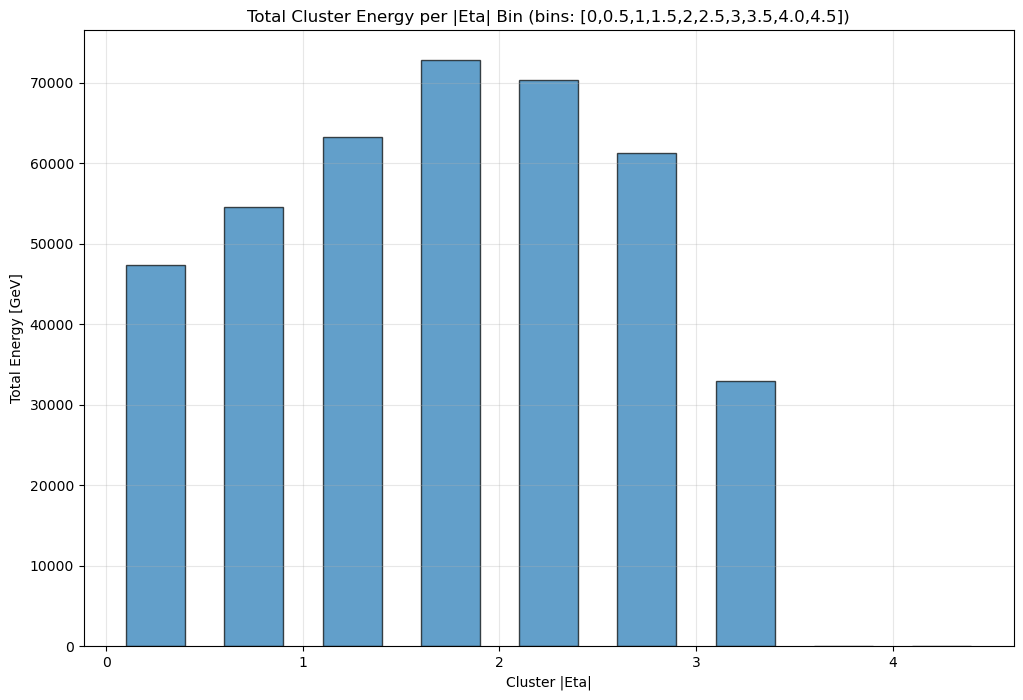

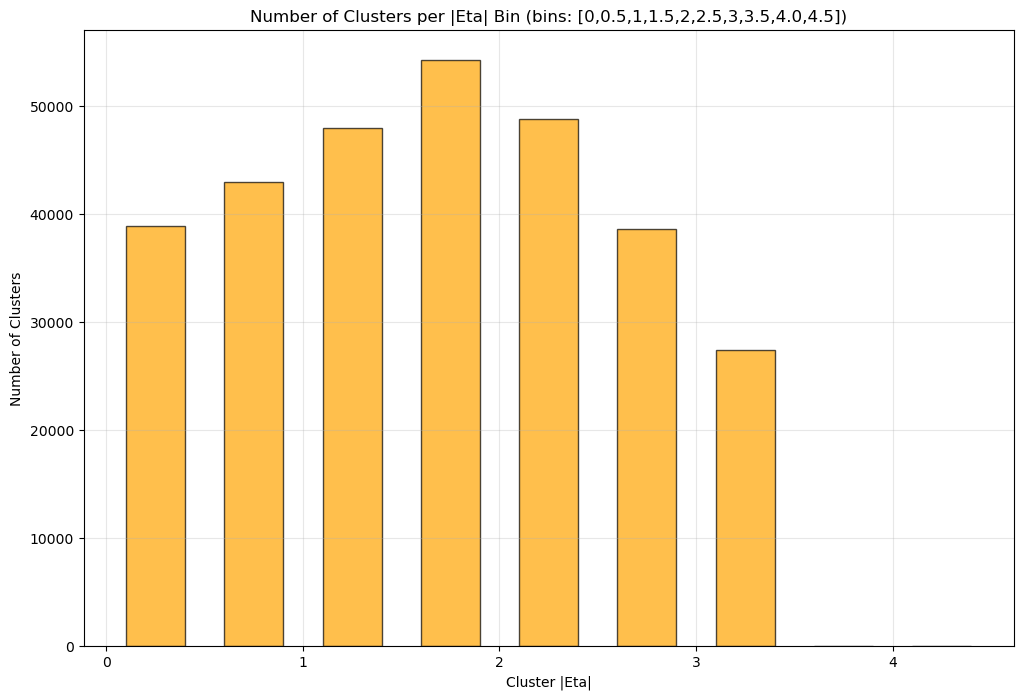

|Eta| bin statistics:
Bin 0: |η| center=0.2, total_energy=47313.24 GeV, num_clusters=38961
Bin 1: |η| center=0.8, total_energy=54614.34 GeV, num_clusters=42980
Bin 2: |η| center=1.2, total_energy=63305.42 GeV, num_clusters=48015
Bin 3: |η| center=1.8, total_energy=72882.86 GeV, num_clusters=54340
Bin 4: |η| center=2.2, total_energy=70381.97 GeV, num_clusters=48878
Bin 5: |η| center=2.8, total_energy=61278.32 GeV, num_clusters=38668
Bin 6: |η| center=3.2, total_energy=33005.76 GeV, num_clusters=27434
Bin 7: |η| center=3.8, total_energy=0.00 GeV, num_clusters=0
Bin 8: |η| center=4.2, total_energy=0.00 GeV, num_clusters=0


In [19]:
# Calculate total energy and number of clusters for each |eta| bin
eta_bins = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4.0, 4.5])  # Custom bins for |eta|
bin_centers = (eta_bins[:-1] + eta_bins[1:]) / 2
total_energies = []
num_clusters = []

for i in range(len(eta_bins)-1):
    eta_mask = (etas_filtered >= eta_bins[i]) & (etas_filtered < eta_bins[i+1])
    energies_in_bin = energies_filtered[eta_mask]
    total_energy = energies_in_bin.sum()
    num_cluster = len(energies_in_bin)
    total_energies.append(total_energy)
    num_clusters.append(num_cluster)

# Bar chart for total energy per |eta| bin
plt.figure(figsize=(12, 8))
plt.bar(bin_centers, total_energies, width=0.3, alpha=0.7, edgecolor='black')
plt.title('Total Cluster Energy per |Eta| Bin (bins: [0,0.5,1,1.5,2,2.5,3,3.5,4.0,4.5])')
plt.xlabel('Cluster |Eta|')
plt.ylabel('Total Energy [GeV]')
plt.grid(True, alpha=0.3)
plt.show()

# Bar chart for number of clusters per |eta| bin
plt.figure(figsize=(12, 8))
plt.bar(bin_centers, num_clusters, width=0.3, alpha=0.7, edgecolor='black', color='orange')
plt.title('Number of Clusters per |Eta| Bin (bins: [0,0.5,1,1.5,2,2.5,3,3.5,4.0,4.5])')
plt.xlabel('Cluster |Eta|')
plt.ylabel('Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

# Print the values
print("|Eta| bin statistics:")
for i, (center, energy, n_clust) in enumerate(zip(bin_centers, total_energies, num_clusters)):
    print(f"Bin {i}: |η| center={center:.1f}, total_energy={energy:.2f} GeV, num_clusters={n_clust}")

In [30]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
from primary.calibration import CALIBRATION
calo = calo_hits

cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .agg(pl.count().alias("count"))
    .rename({"count": "cluster_size"})
    .collect()
)
size_cdf = (
    cluster_stats.lazy()
    .group_by("cluster_size")
    .agg(pl.count().alias("num_clusters"))
    .sort("cluster_size")
    .collect()
    .with_columns([
        pl.col("num_clusters").cum_sum().shift(1).fill_null(0).alias("clusters_lt"),
    ])
    .with_columns([
        (pl.col("clusters_lt") / pl.col("num_clusters").sum() * 100).alias("percentage_lt"),
    ])
)

fig = go.Figure(
    go.Scatter(
        x=size_cdf["cluster_size"],
        y=size_cdf["percentage_lt"],
        mode="markers+lines",
        marker=dict(size=8, color="mediumslateblue"),
        hovertemplate="Partition size < %{x}<br>Share: %{y:.2f}%<extra></extra>",
    )
)
fig.update_layout(
    title="Cumulative share of partitions by size",
    xaxis_title="Partition size (cells)",
    yaxis_title="Percentage of partitions",
    yaxis=dict(range=[0, 100]),
)
fig.show()



cluster_energy_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id", "detector", "total_energy"])
    .explode(["cluster_id", "detector", "total_energy"])
    .join(
        CALIBRATION.lazy().select(["detector", "calib_factor"]),
        on="detector",
    )
    .group_by(["event_id", "cluster_id"])
    .agg([
        pl.len().alias("cluster_size"),
        (pl.col("total_energy") * pl.col("calib_factor")).sum().alias("cluster_energy"),
    ])
    .collect(streaming=True)
)

# 2. Calculate Global Energy Distribution
energy_cdf = (
    cluster_energy_stats.lazy()
    # BUG FIX: Group ONLY by cluster_size. 
    # We want to sum the energy of ALL clusters of size X in the entire dataset.
    .group_by("cluster_size")
    .agg([
        pl.col("cluster_energy").sum().alias("total_energy_at_size"),
    ])
    .sort("cluster_size")
    .with_columns([
        # Cumulative sum of the GLOBAL energy
        pl.col("total_energy_at_size")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("energy_lt_global")
    ])
    .with_columns([
        # Normalize by the grand total energy of the entire dataset
        (pl.col("energy_lt_global") / pl.col("total_energy_at_size").sum() * 100)
        .alias("avg_energy_pct")
    ])
    .collect()
)

# 3. Plot
fig = go.Figure(
    go.Scatter(
        x=energy_cdf["cluster_size"],
        y=energy_cdf["avg_energy_pct"],
        mode="markers+lines",
        marker=dict(size=6, color="darkorchid"),
        line=dict(width=2),
        hovertemplate="Partition size < %{x}<br>Total Energy share: %{y:.2f}%<extra></extra>",
    )
)
fig.update_layout(
    title="Cumulative share of energy by partition size (Global)",
    xaxis_title="Partition size (cells)",
    yaxis_title="Energy share [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white"
)
fig.show()


/tmp/ipykernel_595929/3713621785.py:12: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)

/tmp/ipykernel_595929/3713621785.py:19: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)



/tmp/ipykernel_595929/3713621785.py:62: DeprecationWarning:

the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.



In [ ]:
# 1. Calculate Cluster Count Distribution sorted by Energy
cluster_count_by_energy_cdf = (
    cluster_energy_stats.lazy()
    .group_by("cluster_energy")
    .agg([
        # Count how many clusters exist at this specific energy level
        pl.len().alias("num_clusters_at_energy")
    ])
    .sort("cluster_energy")
    .with_columns([
        # Cumulative sum of the COUNT of clusters
        pl.col("num_clusters_at_energy")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("clusters_lt")
    ])
    .with_columns([
        # Normalize by the total NUMBER of clusters
        (pl.col("clusters_lt") / pl.col("num_clusters_at_energy").sum() * 100)
        .alias("cluster_count_pct")
    ])
    .collect()
)

# 2. Plot
fig = go.Figure(
    go.Scatter(
        x=cluster_count_by_energy_cdf["cluster_energy"],
        y=cluster_count_by_energy_cdf["cluster_count_pct"],
        mode="markers+lines",
        # Teal color to distinguish from energy share plots
        marker=dict(size=4, color="teal"), 
        line=dict(width=2),
        hovertemplate="Cluster Energy < %{x:.2f}<br>Percentage of Clusters: %{y:.2f}%<extra></extra>",
    )
)

fig.update_layout(
    title="Cumulative share of clusters by cluster energy",
    xaxis_title="Cluster Energy",
    yaxis_title="Percentage of Clusters [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white",
)

# Optional: If your energy spans many orders of magnitude, uncomment below:
# fig.update_layout(xaxis_type="log")

fig.show()

In [21]:
# 0. Calculate the Global Target (Truth) Energy
# We sum the energy of ALL target particles across ALL events to get one scalar value.
total_target_energy_global = (
    particles.lazy()
    .select(['event_id', 'particle_id', 'is_target_particle', 'energy'])
    .explode(['is_target_particle', 'particle_id', 'energy'])
    .filter(pl.col('is_target_particle'))
    .select(pl.col('energy').sum())  # Sum everything into one number
    .collect()
    .item()  # Extract the float value
)

print(f"Global Target Energy (Truth): {total_target_energy_global:.2f}")

# ---------------------------------------------------------
# Plot 1: Cumulative Energy Share (Normalized by TRUTH)
# ---------------------------------------------------------

energy_by_energy_cdf = (
    cluster_energy_stats.lazy()
    .group_by("cluster_energy")
    .agg([
        pl.col("cluster_energy").sum().alias("total_energy_at_this_level")
    ])
    .sort("cluster_energy")
    .with_columns([
        # Cumulative sum of reconstructed energy
        pl.col("total_energy_at_this_level")
        .cum_sum()
        .shift(1)
        .fill_null(0)
        .alias("energy_lt_sum")
    ])
    .with_columns([
        # HERE IS THE CHANGE: Normalize by total_target_energy_global
        (pl.col("energy_lt_sum") / total_target_energy_global * 100)
        .alias("energy_share_pct")
    ])
    .collect()
)

fig1 = go.Figure(
    go.Scatter(
        x=energy_by_energy_cdf["cluster_energy"],
        y=energy_by_energy_cdf["energy_share_pct"],
        mode="markers+lines",
        marker=dict(size=4, color="crimson"),
        line=dict(width=2),
        hovertemplate="Cluster Energy < %{x:.2f}<br>Share of Truth Energy: %{y:.2f}%<extra></extra>",
    )
)

fig1.update_layout(
    title=f"Cumulative Reconstructed Energy (Normalized by Target Truth Energy)<br><sup>Global Truth Energy: {total_target_energy_global:.2e}</sup>",
    xaxis_title="Cluster Energy",
    yaxis_title="% of Total Truth Energy",
    # Y-axis might exceed 100 or be less than 100, so we let it auto-scale or set a wide range
    yaxis=dict(range=[0, max(105, energy_by_energy_cdf["energy_share_pct"].max())]),
    template="plotly_white",
)
fig1.show()

# ---------------------------------------------------------
# Plot 2: Cumulative Cluster Count (Standard Normalization)
# ---------------------------------------------------------
# Note: Changing "Total Energy" doesn't usually change the definition of 
# "Percentage of Clusters", so this is normalized by total COUNT (0-100%).

cluster_count_cdf = (
    cluster_energy_stats.lazy()
    .group_by("cluster_energy")
    .agg(pl.len().alias("count_at_level"))
    .sort("cluster_energy")
    .with_columns([
        pl.col("count_at_level").cum_sum().shift(1).fill_null(0).alias("count_lt")
    ])
    .with_columns([
        (pl.col("count_lt") / pl.col("count_at_level").sum() * 100).alias("count_pct")
    ])
    .collect()
)

fig2 = go.Figure(
    go.Scatter(
        x=cluster_count_cdf["cluster_energy"],
        y=cluster_count_cdf["count_pct"],
        mode="markers+lines",
        marker=dict(size=4, color="teal"),
        line=dict(width=2),
        hovertemplate="Cluster Energy < %{x:.2f}<br>% of Clusters: %{y:.2f}%<extra></extra>",
    )
)

fig2.update_layout(
    title="Cumulative Share of Cluster Count by Energy",
    xaxis_title="Cluster Energy",
    yaxis_title="Percentage of Clusters [%]",
    yaxis=dict(range=[0, 100]),
    template="plotly_white",
)
fig2.show()

# ---------------------------------------------------------
# Plot 3: Scatter Plot (Energy vs Size)
# ---------------------------------------------------------

fig3 = go.Figure(
    go.Scattergl(
        x=cluster_energy_stats["cluster_energy"],
        y=cluster_energy_stats["cluster_size"],
        mode="markers",
        marker=dict(
            size=3,
            color="royalblue",
            opacity=0.4
        ),
        hovertemplate="Energy: %{x:.2f}<br>Size: %{y}<extra></extra>",
    )
)

fig3.update_layout(
    title="Cluster Size vs. Cluster Energy",
    xaxis_title="Cluster Energy",
    yaxis_title="Cluster Size (cells)",
    template="plotly_white",
    # xaxis_type="log", # Uncomment for log scale
    # yaxis_type="log"
)
fig3.show()

Global Target Energy (Truth): 4258810.00


NameError: name 'cluster_energy_stats' is not defined